<a href="https://colab.research.google.com/github/MarianaMayumeCaniza/PROJETOAPLICADO4_2026.01/blob/main/Entregas_Projeto/Entrega3_SeriesTemporais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 3**

---

# **Etapa 3 - Implementação Parcial**
---

In [ ]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Amarildo Maciel Junior, 10441652' #@param {type:"string"}
Aluno2 = 'Mariana Mayume Caniza, 10290174' #@param {type:"string"}
Aluno3 = 'Stella Amaral de Campos, 10441310' #@param {type:"string"}
Aluno4 = 'None' #@param {type:"string"}
Aluno5 = 'None' #@param {type:"string"}

# **Introdução**

O presente projeto desenvolve-se no contexto da Ciência de Dados aplicada à Economia Industrial. De acordo com Fernandes (2026), uma série temporal é um conjunto de observações ordenadas no tempo e coletadas em intervalos regulares. Neste trabalho, o foco recai sobre o Índice de Produção Física Industrial (PIM-PF), um indicador vital para medir o dinamismo econômico de um país.

### 1.1 Problema
A volatilidade da produção industrial brasileira apresenta um desafio para os gestores de infraestrutura e produção. Sem uma análise preditiva, a indústria enfrenta o risco de subutilização de recursos ou gargalos logísticos. O problema selecionado é a incerteza no planejamento produtivo, que muitas vezes leva ao desperdício de insumos e energia, dificultando a construção de uma infraestrutura resiliente e sustentável.

### 1.2 Motivação e Justificativa
A relevância deste tema fundamenta-se nos Objetivos de Desenvolvimento Sustentável (ODS) da Organização das Nações Unidas (ONU). A capacidade de prever a produção permite que a infraestrutura logística e energética do país seja planejada com maior precisão (ODS 9 – Indústria, Inovação e Infraestrutura). Ao identificar padrões sazonais, as indústrias podem ajustar seu estoque e produção, reduzindo desperdícios de matéria-prima (ODS 12 – Consumo e Produção Responsáveis). A solução proposta consiste em um produto analítico baseado em modelos estatísticos de séries temporais que funcionará como ferramenta de auxílio à tomada de decisão para associações industriais e gestores governamentais.

### 1.3 Objetivo Geral
Desenvolver um modelo preditivo univariado para o índice de produção industrial brasileira.

### 1.4 Objetivos Específicos
Realizar a decomposição clássica da série temporal para isolar tendência, sazonalidade e ruído.
Classificar a série quanto à sua estacionariedade e linearidade.
Projetar valores futuros que sirvam de subsídio para o planejamento estratégico do cliente, visando à redução de custos operacionais e desperdícios.

### 1.5 Base de Dados
O projeto utilizará dados secundários oficiais obtidos via plataforma SIDRA do Instituto Brasileiro de Geografia e Estatística — Pesquisa Industrial Mensal – Produção Física (PIM-PF), Tabela 8159. Trata-se de uma série univariada com o número-índice da produção física industrial (base fixa mensal sem ajuste sazonal), cobrindo o período de janeiro de 2006 a dezembro de 2022.

# **Referencial Teórico**

A análise de séries temporais é um campo da estatística voltado ao estudo de dados coletados sequencialmente ao longo do tempo. Segundo Morettin e Toloi (2018), os principais componentes de uma série temporal são: tendência (movimento de longo prazo), sazonalidade (padrões que se repetem em períodos fixos) e ruído (variações aleatórias não explicadas pelos demais componentes).

Para verificar se uma série é estacionária — condição exigida por grande parte dos modelos preditivos —, utiliza-se o Teste de Dickey-Fuller Aumentado (ADF). Uma série é considerada estacionária quando sua média e variância são constantes ao longo do tempo (p-valor ≤ 0,05). Caso contrário, transformações como diferenciação são aplicadas.

Entre as técnicas de modelagem para séries temporais, destacam-se: (1) modelos ARIMA (AutoRegressive Integrated Moving Average), amplamente utilizados para séries univariadas estacionárias; (2) Suavização Exponencial (ETS), que pondera observações recentes com maior peso; e (3) modelos de decomposição clássica, que separam os componentes da série para análise individual. Cada abordagem apresenta vantagens — ARIMA é flexível para diferentes estruturas de autocorrelação, enquanto ETS é computacionalmente simples e interpretável.

Trabalhos correlatos utilizando o índice PIM-PF do IBGE geralmente empregam ARIMA ou SARIMA (versão sazonal do ARIMA) para capturar tanto a tendência quanto os padrões mensais recorrentes da produção industrial brasileira (MORETTIN; TOLOI, 2018).



# **Diagrama de Solução**

Apresente e discuta o diagrama da solução proposta. Utilize o pipeline proposto inicialmente como base.

# **Pré-processamento dos dados**

Exploração e análise dos dados. Discussão e análise dos dados empregados (qualidade, limitações, simplicações ou recortes adotados etc.). Tarefas de preparação dos dados (transformações, compactação e encodes, junções de dados etc.).

## Brasil Industrial Geral Numero Indice (periodo: Jan-2002 - Dez-2022)

In [ ]:
import pandas as pd
import requests
# A URL que você encontrou na imagem (Parâmetros para a API)
api_url = "https://apisidra.ibge.gov.br/values/t/8159/n1/all/v/11599/p/all/c544/129314/d/v11599%201"

# Coletando os dados Industria Geral Brasil via API
response = requests.get(api_url)
data = response.json()

# Transformando em um DataFrame (Tabela)
df_BrasilGeral = pd.DataFrame(data)
#print(df_BrasilGeral.head())

# Limpeza rápida: a primeira linha do IBGE é sempre o cabeçalho descritivo
df_BrasilGeral.columns = df_BrasilGeral.iloc[0]
print(df_BrasilGeral.head())

df_BrasilGeral = df_BrasilGeral.iloc[1:]
#print(df_BrasilGeral.head())


0  Nível Territorial (Código)  Nível Territorial  Unidade de Medida (Código)  \
0  Nível Territorial (Código)  Nível Territorial  Unidade de Medida (Código)   
1                           1             Brasil                          30   
2                           1             Brasil                          30   
3                           1             Brasil                          30   
4                           1             Brasil                          30   

0  Unidade de Medida  Valor  Brasil (Código)  Brasil  Variável (Código)  \
0  Unidade de Medida  Valor  Brasil (Código)  Brasil  Variável (Código)   
1      Número-índice   72.4                1  Brasil              11599   
2      Número-índice   69.7                1  Brasil              11599   
3      Número-índice   77.4                1  Brasil              11599   
4      Número-índice   79.6                1  Brasil              11599   

0                          Variável  Mês (Código)             Mês  \

In [ ]:
# Selecionando apenas o que importa: Data (Mês) e o Valor do Índice
BrasilGeral = df_BrasilGeral[['Mês (Código)', 'Valor']].copy()
BrasilGeral.columns = ['Data', 'Indice']
#print(BrasilGeral.head())

# Convertendo para o formato correto
BrasilGeral['Data'] = pd.to_datetime(BrasilGeral['Data'], format='%Y%m')
BrasilGeral['Indice'] = pd.to_numeric(BrasilGeral['Indice'], errors='coerce')
#Organizando por data
BrasilGeral = BrasilGeral.set_index('Data').sort_index()

print("Coleta Brasil Industrial Geral")
print(BrasilGeral.head())

Coleta Brasil Industrial Geral
            Indice
Data              
2002-01-01    72.4
2002-02-01    69.7
2002-03-01    77.4
2002-04-01    79.6
2002-05-01    80.4


In [ ]:
# Forçando a frequência mensal (Month Start)
BrasilGeral = BrasilGeral.asfreq('MS')
print(BrasilGeral)

# 3. Checando se o asfreq encontrou algum mês faltando
buracos = BrasilGeral['Indice'].isnull().sum()
if buracos > 0:
    print(f"Meses Faltantes: {buracos} ")
    BrasilGeral['Indice'] = BrasilGeral['Indice'].interpolate()
else:
    print("Sem 0's. DataFrame Pronto para uso")# Forçando a frequência mensal (Month Start)
BrasilGeral = BrasilGeral.asfreq('MS')
print(BrasilGeral)

# 3. Checando se o asfreq encontrou algum mês faltando
buracos = BrasilGeral['Indice'].isnull().sum()
if buracos > 0:
    print(f"Meses Faltantes: {buracos} ")
    BrasilGeral['Indice'] = BrasilGeral['Indice'].interpolate()
else:
    print("Sem 0's. DataFrame Pronto para uso")

            Indice
Data              
2002-01-01    72.4
2002-02-01    69.7
2002-03-01    77.4
2002-04-01    79.6
2002-05-01    80.4
...            ...
2022-08-01    96.0
2022-09-01    91.8
2022-10-01    91.3
2022-11-01    87.0
2022-12-01    78.2

[252 rows x 1 columns]
Sem 0's. DataFrame Pronto para uso
            Indice
Data              
2002-01-01    72.4
2002-02-01    69.7
2002-03-01    77.4
2002-04-01    79.6
2002-05-01    80.4
...            ...
2022-08-01    96.0
2022-09-01    91.8
2022-10-01    91.3
2022-11-01    87.0
2022-12-01    78.2

[252 rows x 1 columns]
Sem 0's. DataFrame Pronto para uso


In [ ]:
# Verifica se existe alguma data repetida (retorna True ou False)
duplicata = BrasilGeral.index.duplicated().any()

if duplicata:
    quantidade = BrasilGeral.index.duplicated().sum()
    print(f"Existem {quantidade} datas duplicadas")
    BrasilGeral = BrasilGeral[~BrasilGeral.index.duplicated(keep='first')]
else:
    print("Não existem datas duplicadas. O calendário está limpo!")

Não existem datas duplicadas. O calendário está limpo!


In [ ]:
#Valores negativos!
import numpy as np
# --- SANEAMENTO DE VALORES IMPOSSÍVEIS ---

# 1. Checar se existem zeros ou negativos
invalidos = (BrasilGeral['Indice'] <= 0).sum()

if invalidos > 0:
    print(f"Existem {invalidos} valor(es) zero ou negativo(s). Tratando como 'vazio' (NaN)...")
    # Transforma apenas os valores problemáticos em NaN
    BrasilGeral.loc[BrasilGeral['Indice'] <= 0, 'Indice'] = np.nan
    BrasilGeral['Indice'] = BrasilGeral['Indice'].interpolate()

else:
    print("Não existem valores zero ou negativos na série. A produção está positiva!")


Não existem valores zero ou negativos na série. A produção está positiva!


In [ ]:
#Valores Distonantes, distintos, possiveis outliers com base na media dos 6meses anteriores e 6 meses posteriores

# Criar média e desvio padrão móvel de 12 meses
# O 'center=True' olha 6 meses para trás e 6 para frente
rolling_mean = BrasilGeral['Indice'].rolling(window=12, center=True).mean()
rolling_std = BrasilGeral['Indice'].rolling(window=12, center=True).std()

# Calcular o Z-Score (quantos desvios o ponto está longe da média)
z_scores = (BrasilGeral['Indice'] - rolling_mean) / rolling_std

# Checagem dos Outliers (|z| > 3)
outliers_encontrados = z_scores.abs() > 3

if outliers_encontrados.any():
    qtd_outliers = outliers_encontrados.sum()
    print(f"Numero de possiveis outliers: {qtd_outliers} ")

    # Mostrar quais datas são para você conferir
    print(BrasilGeral[outliers_encontrados].index)

    # Transforma esses saltos em "vazio" para serem corrigidos depois
    BrasilGeral.loc[outliers_encontrados, 'Indice'] = np.nan
    BrasilGeral['Indice'] = BrasilGeral['Indice'].interpolate()
else:
    print("Nenhum salto absurdo detectado. Dados Normais")

Nenhum salto absurdo detectado. Dados Normais


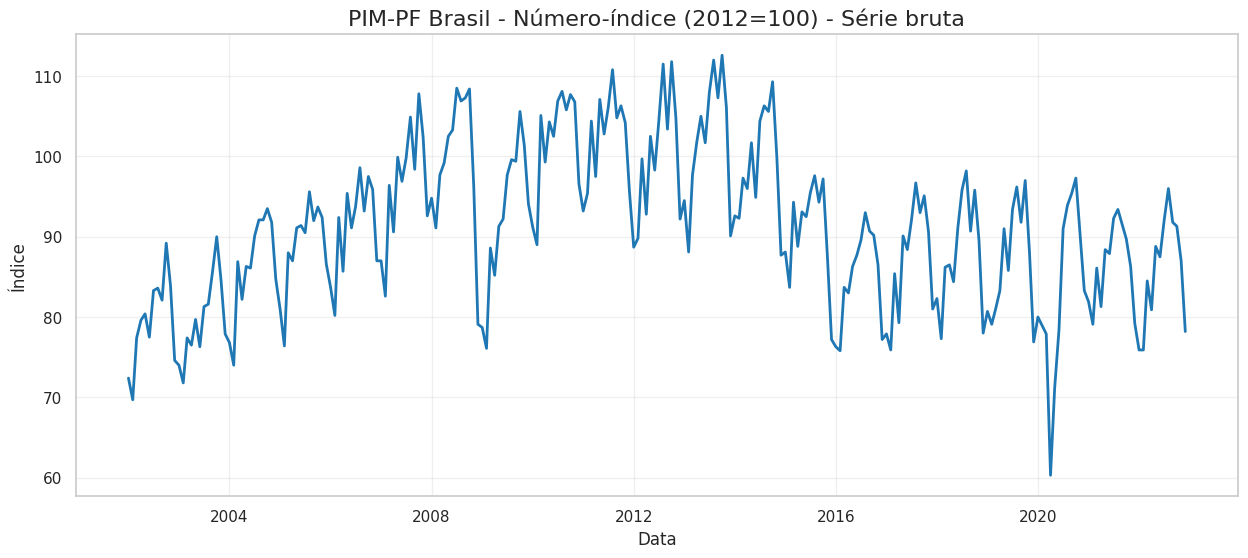

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definindo o estilo e o tamanho da imagem (proporção larga como a sua)
plt.figure(figsize=(15, 6))
sns.set_theme(style="whitegrid") # Cria esse fundo com grades claras

# 2. Plotando a linha (o 'Indice' que limpamos antes)
plt.plot(BrasilGeral.index, BrasilGeral['Indice'], color='#1f77b4', linewidth=2)

# 3. Personalizando os textos (Exatamente como na sua imagem)
plt.title('PIM-PF Brasil - Número-índice (2012=100) - Série bruta', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Índice', fontsize=12)

# 4. Ajuste fino da grade (deixando ela mais suave)
plt.grid(True, alpha=0.3)

# Exibir o gráfico
plt.show()

# **EDA**

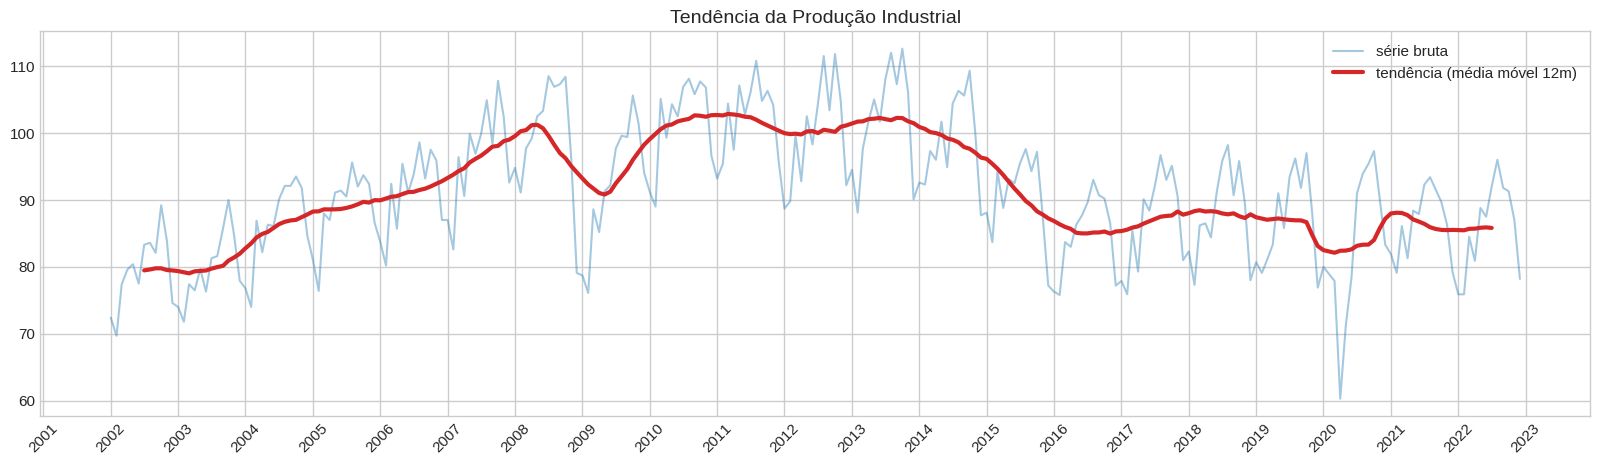

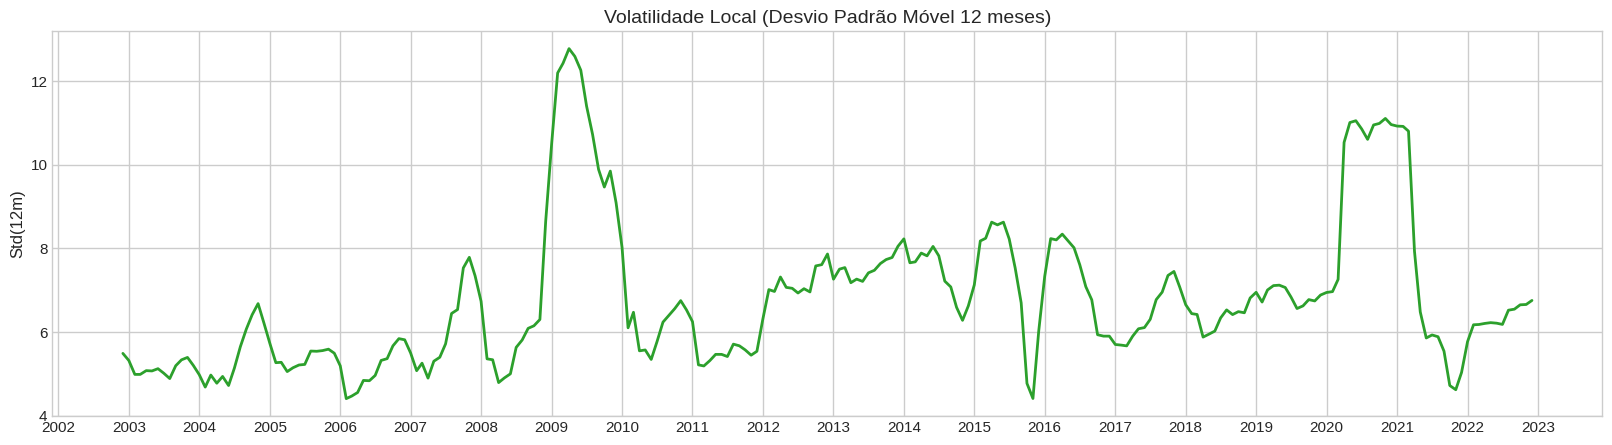

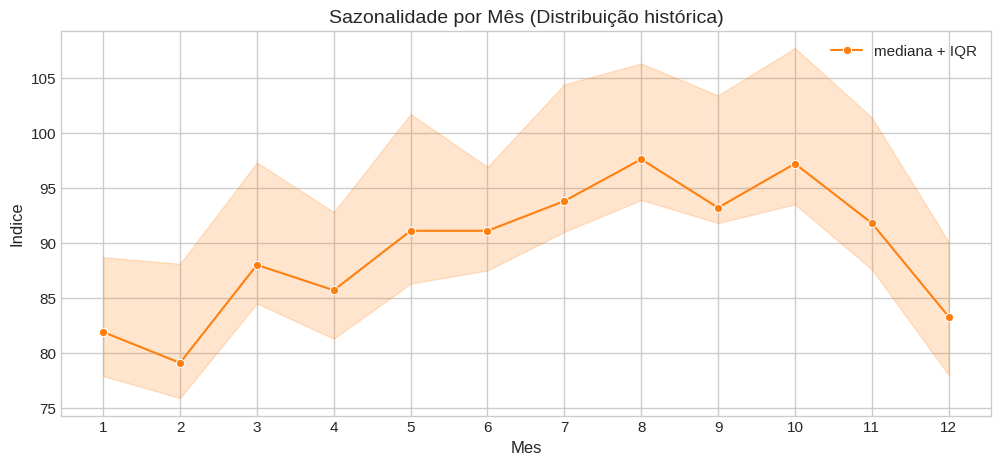

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
# Configuração de estilo geral
plt.style.use('seaborn-v0_8-whitegrid')

# --- 1. GRÁFICO DE TENDÊNCIA (Média Móvel 12m) ---
plt.figure(figsize=(20, 5))
plt.plot(BrasilGeral.index, BrasilGeral['Indice'], alpha=0.4, label='série bruta', color='tab:blue')
plt.plot(BrasilGeral.index, BrasilGeral['Indice'].rolling(12, center=True).mean(),
         color='tab:red', linewidth=3, label='tendência (média móvel 12m)')
ax = plt.gca() # Pega o "eixo" do gráfico para podermos configurá-lo
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45) # 4. Inclina os anos em 45 graus para eles não se atropelarem [cite: 1148, 1149]
plt.title('Tendência da Produção Industrial', fontsize=14)
plt.legend()
plt.show()

# --- 2. GRÁFICO DE VOLATILIDADE (Desvio Padrão Móvel) ---
plt.figure(figsize=(20, 5))
plt.plot(BrasilGeral.index, BrasilGeral['Indice'].rolling(12).std(), color='tab:green', linewidth=2)
plt.title('Volatilidade Local (Desvio Padrão Móvel 12 meses)', fontsize=14)
ax = plt.gca() # Pega o "eixo" do gráfico para podermos configurá-lo
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.ylabel('Std(12m)')
plt.show()

# --- 3. GRÁFICO DE SAZONALIDADE (Distribuição Mensal) ---
# Primeiro, criamos uma coluna apenas com o mês (1 a 12)
BrasilGeral['Mes'] = BrasilGeral.index.month
plt.figure(figsize=(12, 5))
sns.lineplot(data=BrasilGeral, x='Mes', y='Indice', estimator='median', errorbar=('pi', 50),
             color='tab:orange', marker='o', label='mediana + IQR')
plt.xticks(range(1, 13))
plt.title('Sazonalidade por Mês (Distribuição histórica)', fontsize=14)
plt.show()

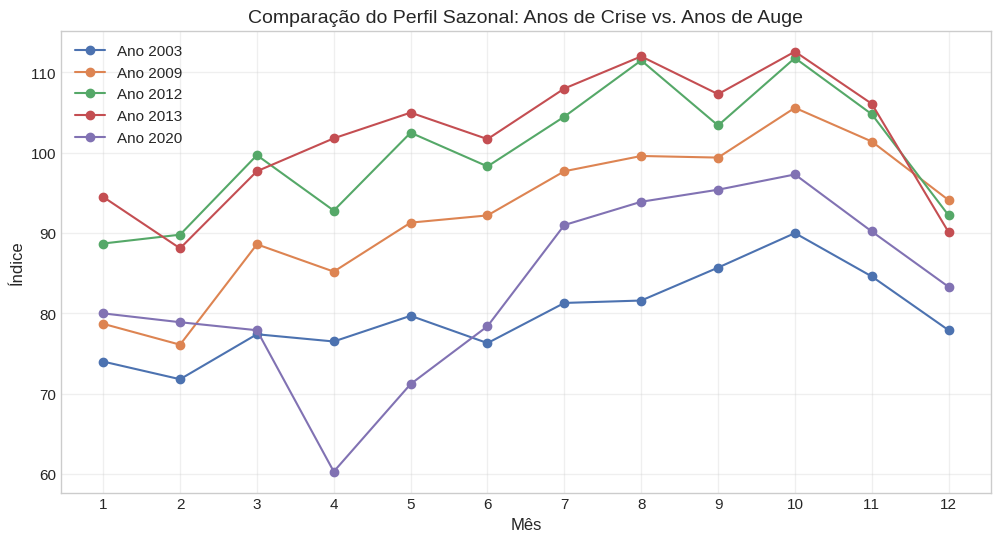

In [9]:
import matplotlib.pyplot as plt

# Criando um gráfico para comparar os anos que você escolheu
anos_para_comparar = [2003, 2009, 2012, 2013, 2020]

plt.figure(figsize=(12, 6))

for ano in anos_para_comparar:
    # Filtramos apenas os dados daquele ano específico
    dados_ano = BrasilGeral[BrasilGeral.index.year == ano]

    # Plotamos: o eixo X será apenas o mês (1 a 12)
    plt.plot(dados_ano.index.month, dados_ano['Indice'], marker='o', label=f'Ano {ano}')

plt.title('Comparação do Perfil Sazonal: Anos de Crise vs. Anos de Auge', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Índice')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

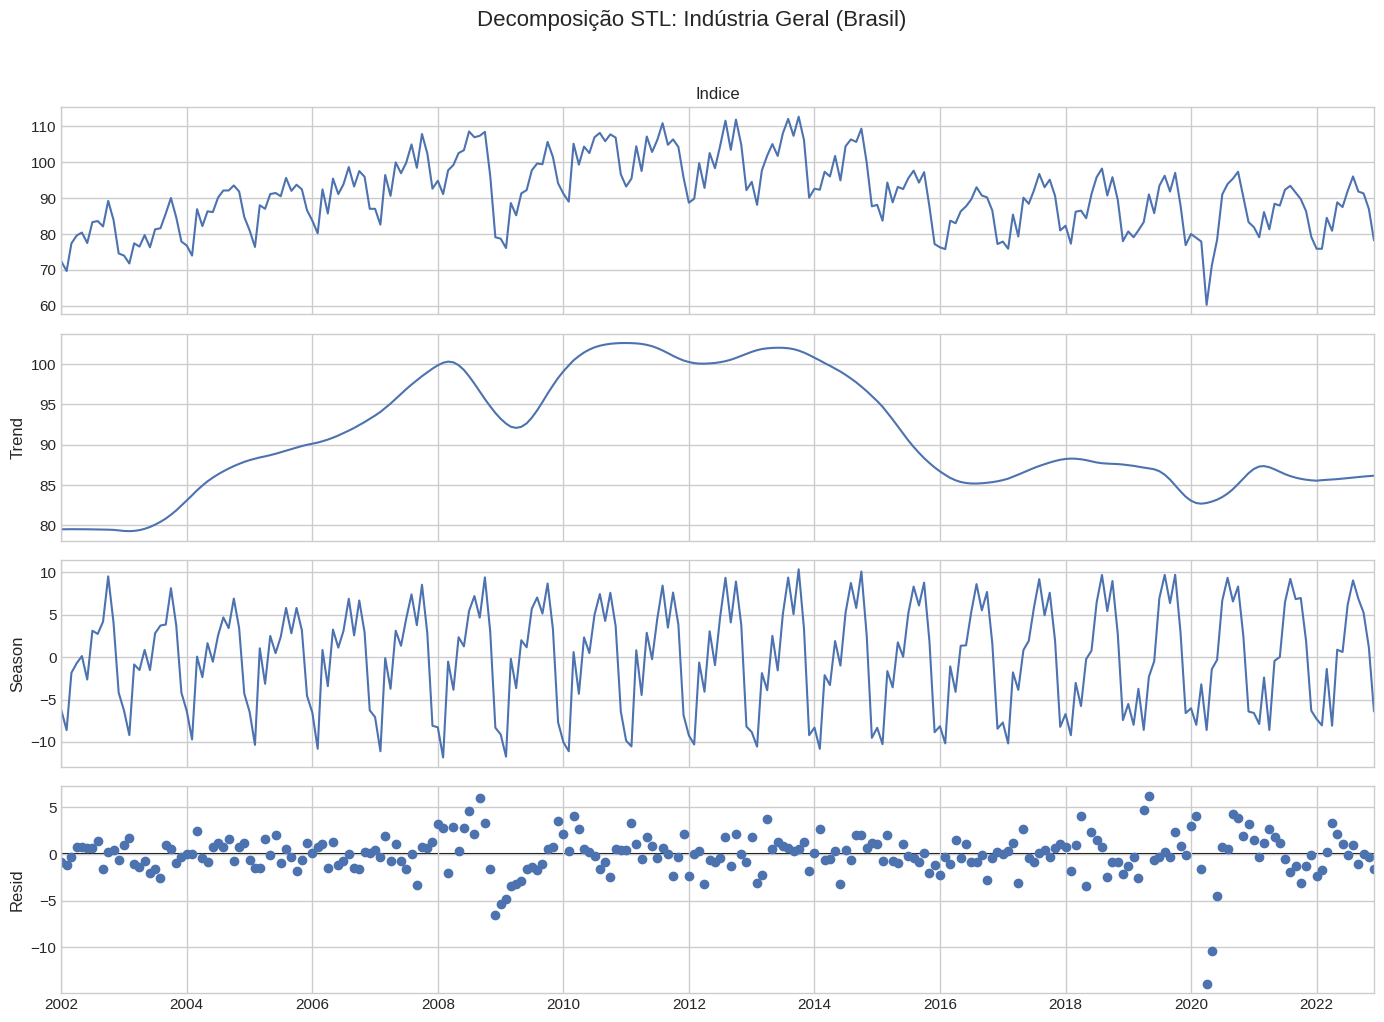

In [10]:
from statsmodels.tsa.seasonal import STL

# Executando a decomposição
# O 'period=12' avisa ao Python que o padrão se repete a cada 12 meses [cite: 728]
stl = STL(BrasilGeral['Indice'], period=12)
res = stl.fit()

# Gerando o gráfico com os 4 componentes
fig = res.plot()
fig.set_size_inches(14, 10) # Ajusta o tamanho para caber no seu relatório
plt.suptitle('Decomposição STL: Indústria Geral (Brasil)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# 1. Calculando a EVM (Variação Mensal %)
# Compara o mês atual com o mês imediatamente anterior
BrasilGeral['EVM'] = BrasilGeral['Indice'].pct_change(1) * 100

# 2. Calculando a AVA (Variação Acumulada 12 meses %)
# Compara o mês atual com o mesmo mês do ano anterior
BrasilGeral['AVA'] = BrasilGeral['Indice'].pct_change(12) * 100

# Visualizando os novos dados
print(BrasilGeral[['Indice', 'EVM', 'AVA']].tail())

            Indice        EVM       AVA
Data                                   
2022-08-01    96.0   4.347826  2.783726
2022-09-01    91.8  -4.375000  0.327869
2022-10-01    91.3  -0.544662  1.783724
2022-11-01    87.0  -4.709748  0.811124
2022-12-01    78.2 -10.114943 -1.262626


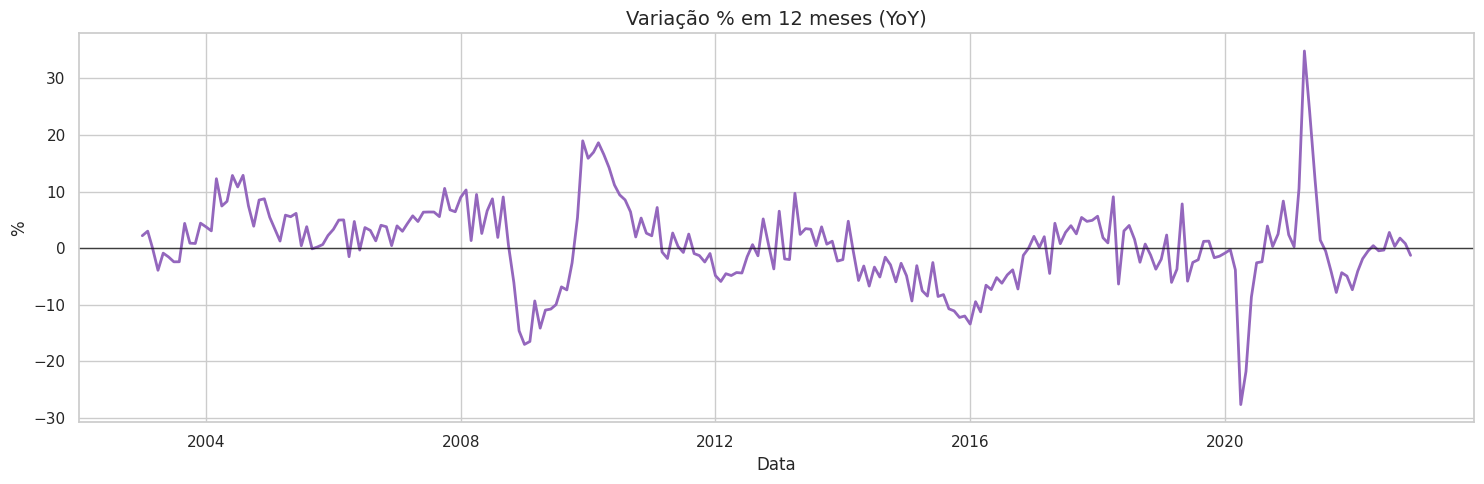

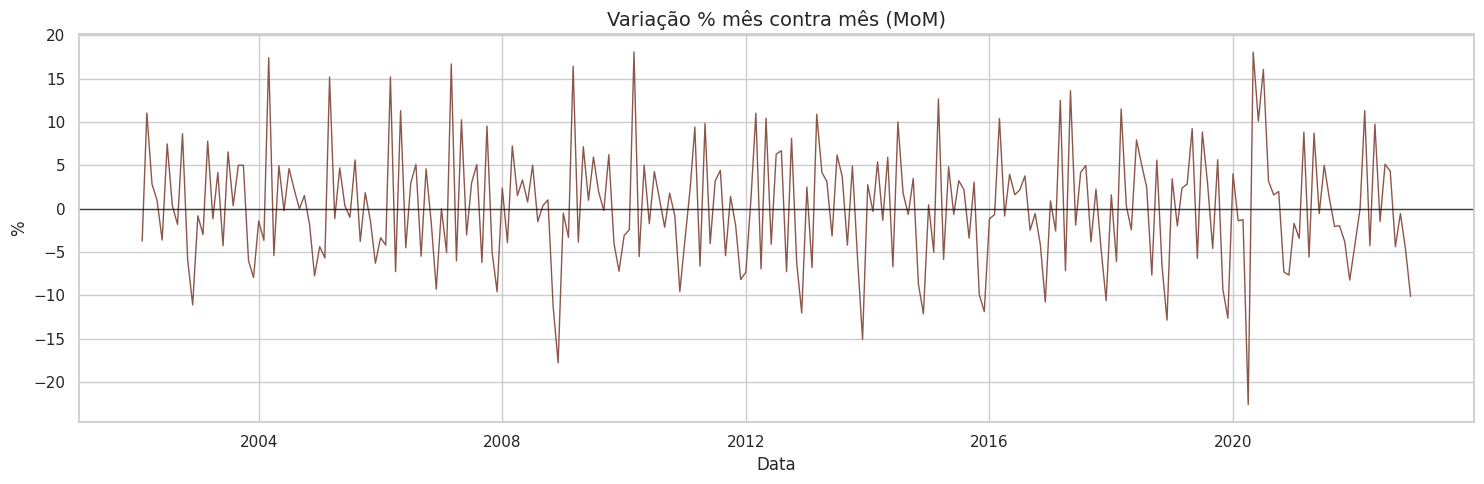

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo para parecer profissional como o seu exemplo
sns.set_theme(style="whitegrid")

# --- 1. GRÁFICO DE VARIAÇÃO ACUMULADA (AVA / YoY %) ---
plt.figure(figsize=(15, 5))
plt.plot(BrasilGeral.index, BrasilGeral['AVA'], color='#9467bd', linewidth=2) # Roxo como na imagem 4
plt.axhline(0, color='black', linewidth=1, alpha=0.7) # Linha de referência no zero
plt.title('Variação % em 12 meses (YoY)', fontsize=14)
plt.ylabel('%')
plt.xlabel('Data')
plt.tight_layout()
plt.show()

# --- 2. GRÁFICO DE VARIAÇÃO MENSAL (EVM / MoM %) ---
plt.figure(figsize=(15, 5))
plt.plot(BrasilGeral.index, BrasilGeral['EVM'], color='#8c564b', linewidth=1) # Marrom como na imagem 5
plt.axhline(0, color='black', linewidth=1, alpha=0.7)
plt.title('Variação % mês contra mês (MoM)', fontsize=14)
plt.ylabel('%')
plt.xlabel('Data')
plt.tight_layout()
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller

def testar_estacionariedade(serie, nome_serie):
    print(f"--- Teste ADF: {nome_serie} ---")
    resultado = adfuller(serie.dropna()) # O dropna garante que meses vazios não quebrem o teste

    p_valor = resultado[1]
    estatistica_adf = resultado[0]

    print(f'Estatística ADF: {estatistica_adf:.4f}')
    print(f'P-valor: {p_valor:.4f}')

    # Interpretando o resultado (Regra de Ouro: 5%)
    if p_valor <= 0.05:
        print("A série é ESTACIONÁRIA (p <= 0.05).")

    else:
        print("A série NÃO é estacionária (p > 0.05).")
        print("Aplicar a Diferenciação (diff) ou Log.")

# Rodando para a sua série principal
testar_estacionariedade(BrasilGeral['Indice'], "Produção Industrial Bruta")

--- Teste ADF: Produção Industrial Bruta ---
Estatística ADF: -2.1197
P-valor: 0.2367
A série NÃO é estacionária (p > 0.05).
Aplicar a Diferenciação (diff) ou Log.


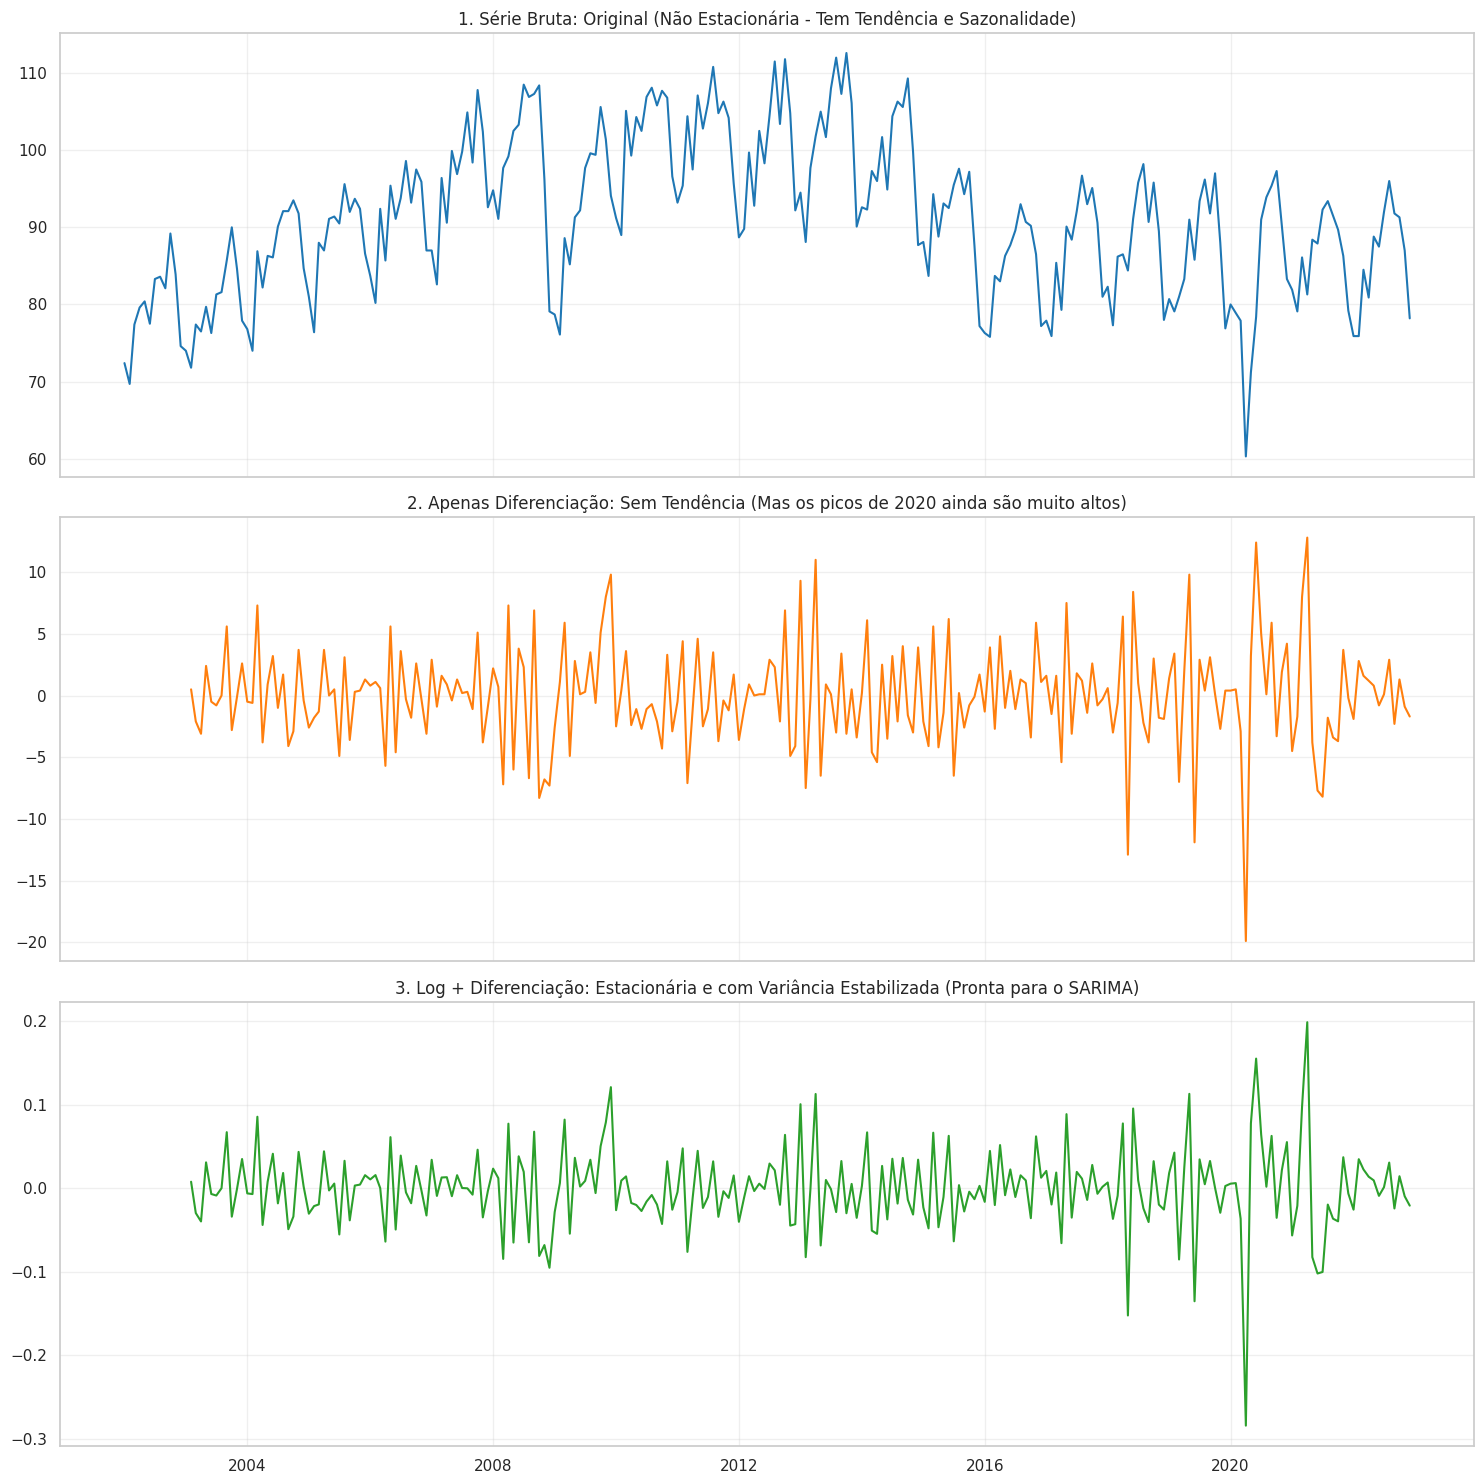

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Criando a versão apenas com Diferenciação (Simples + Sazonal)
# Isso remove a tendência e o padrão de 12 meses
serie_so_diff = BrasilGeral['Indice'].diff().diff(12)

# 2. Criando a versão Logaritmo + Diferenciação (A mais completa)
# Primeiro achata os picos com Log, depois remove a tendência
serie_log_diff = np.log(BrasilGeral['Indice']).diff().diff(12)

# --- Plotando o Comparativo ---
fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

# Gráfico 1: Série Bruta (Onde você começou)
axes[0].plot(BrasilGeral.index, BrasilGeral['Indice'], color='tab:blue')
axes[0].set_title('1. Série Bruta: Original (Não Estacionária - Tem Tendência e Sazonalidade)')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Apenas Diferenciação (Remove a "Escada")
axes[1].plot(BrasilGeral.index, serie_so_diff, color='tab:orange')
axes[1].set_title('2. Apenas Diferenciação: Sem Tendência (Mas os picos de 2020 ainda são muito altos)')
axes[1].grid(True, alpha=0.3)

# Gráfico 3: Log + Diferenciação (O "Padrão Ouro")
axes[2].plot(BrasilGeral.index, serie_log_diff, color='tab:green')
axes[2].set_title('3. Log + Diferenciação: Estacionária e com Variância Estabilizada (Pronta para o SARIMA)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
import numpy as np

# 1. Criando a série 'blindada' (Log + Diferença de 1 mês + Diferença de 12 meses)
# O dropna() é essencial porque a diferenciação cria 'buracos' no início da série
serie_para_modelo = np.log(BrasilGeral['Indice']).diff().diff(12).dropna()

# 2. Testando a estacionariedade de novo
testar_estacionariedade(serie_para_modelo, "Série Log-Diferenciada (Final)")

--- Teste ADF: Série Log-Diferenciada (Final) ---
Estatística ADF: -6.4196
P-valor: 0.0000
A série é ESTACIONÁRIA (p <= 0.05).


# Modelo Base #

### **1. Técnicas de Modelagem Selecionadas**

Para atender ao requisito de comparação de modelos, selecionamos:

1.  **SARIMA (Seasonal AutoRegressive Integrated Moving Average)**: Uma extensão do modelo ARIMA que suporta explicitamente dados de séries temporais com um componente sazonal. É ideal para a indústria, pois lida com a não estacionariedade e os ciclos anuais.

2.  **Holt-Winters (Suavização Exponencial Tripla)**: Um modelo que decompõe a série em nível, tendência e sazonalidade de forma independente. Ele é robusto para lidar com variações sazonais que podem mudar de amplitude ao longo do tempo.

## Preparação dos Dados - Treino e Teste ##

In [19]:
# Separando os dados: usaremos até 2021 para treinar e o ano de 2022 para testar a precisão
# Usando os nomes específicos do seu projeto: BrasilGeral e Indice
train = BrasilGeral['Indice'][:-12]
test = BrasilGeral['Indice'][-12:]

print(f"Dados de Treino: {len(train)} meses")
print(f"Dados de Teste: {len(test)} meses (Ano de 2022)")

Dados de Treino: 240 meses
Dados de Teste: 12 meses (Ano de 2022)


### Implementação dos Modelos ###

In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

#Para Sarima teremos que ajustar os dados para serem estacionarios
# 1. Ajustando o Modelo SARIMA
train_sarima = np.log(train)

model_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_fit = model_sarima.fit(disp=False, method='nm', maxiter=500)
pred_sarima = sarima_fit.forecast(steps=12)

# 2. Ajustando o Modelo Holt-Winters
model_hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
hw_fit = model_hw.fit()
pred_hw = hw_fit.forecast(steps=12)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


### Avaliação e Gráfico Comparativo ###

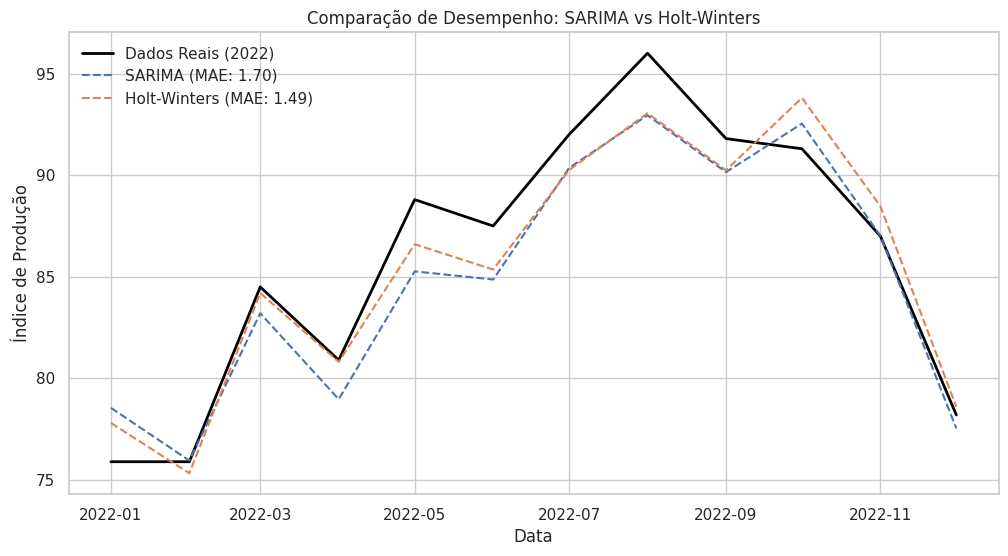

Métricas SARIMA -> MAE: 1.70 | RMSE: 2.01
Métricas Holt-Winters -> MAE: 1.49 | RMSE: 1.74


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Função para calcular métricas
def calcular_metricas(real, pred):
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    return mae, rmse

mae_s, rmse_s = calcular_metricas(test, pred_sarima)
mae_hw, rmse_hw = calcular_metricas(test, pred_hw)

# Plotagem Gráfica
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Dados Reais (2022)', color='black', linewidth=2)
plt.plot(test.index, pred_sarima, label=f'SARIMA (MAE: {mae_s:.2f})', linestyle='--')
plt.plot(test.index, pred_hw, label=f'Holt-Winters (MAE: {mae_hw:.2f})', linestyle='--')
plt.title('Comparação de Desempenho: SARIMA vs Holt-Winters')
plt.ylabel('Índice de Produção')
plt.xlabel('Data')
plt.legend()
plt.show()

print(f"Métricas SARIMA -> MAE: {mae_s:.2f} | RMSE: {rmse_s:.2f}")
print(f"Métricas Holt-Winters -> MAE: {mae_hw:.2f} | RMSE: {rmse_hw:.2f}")

# **Cronograma de Atividades**

| Atividade | Descrição | Status |
|:---|:---|:---|
| **Entrega 1** | Definição do tema, objetivos e descrição da base de dados (PIM-PF). | Concluído |
| **Entrega 2** | Análise exploratória (EDA), decomposição da série e levantamento de técnicas. | Concluído |
| **Entrega 3** | Implementação dos modelos SARIMA e Holt-Winters e comparação de desempenho. | **Em andamento** |
| **Entrega Final** | Geração de previsões futuras, conclusões e documentação consolidada. | A iniciar |

# **Referências**

BRASIL. Instituto Brasileiro de Geografia e Estatística. Pesquisa Industrial Mensal – Produção Física (PIM-PF): Tabela 8159. Rio de Janeiro: IBGE, 2023. Disponível em: https://sidra.ibge.gov.br/tabela/8159. Acesso em: 28 fev. 2026.

FERNANDES, Leandro Carlos. Projeto Aplicado IV: Aula 1 – Introdução às Séries Temporais. São Paulo: Universidade Presbiteriana Mackenzie, 2026. Texto de apoio.

MORETTIN, P. A.; TOLOI, C. M. C. Análise de séries temporais. 3. ed. São Paulo: Blucher, 2018. v. 1.

ORGANIZAÇÃO DAS NAÇÕES UNIDAS. Objetivos de Desenvolvimento Sustentável: ODS 9 e ODS 12. Disponível em: https://brasil.un.org/pt-br/sdgs. Acesso em: 28 fev. 2026.




In [ ]:
#@title **Avaliação**
EDA_e_preprocessamento = 10 #@param {type:"slider", min:0, max:10, step:1}

Modelo_base = 10 #@param {type:"slider", min:0, max:10, step:1}

In [ ]:
#@title **Nota Final**
nota = 0.50*EDA_e_preprocessamento + 0.50*Modelo_base

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)#@title **Nota Final**
nota = 0.50*EDA_e_preprocessamento + 0.50*Modelo_base

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Amarildo Maciel Junior,10.0
1,Mariana Mayume Caniza,10.0
2,Stella Amaral de Campos,10.0


Nota final do trabalho 10.0



,nome,nota
0,Amarildo Maciel Junior,10.0
1,Mariana Mayume Caniza,10.0
2,Stella Amaral de Campos,10.0
